# Tigrinya Word Embeddings from Scratch

## Skip-gram Neural Network in Pure Python

**Goal:** train word embeddings for Tigrinya with a skip-gram model implemented
by hand: forward pass, stable softmax, loss, gradients and SGD.

**Constraints:** only Python lists, loops, `math` and `random`. No NumPy, no
automatic differentiation, no neural-network libraries and no pretrained embeddings.

### Pipeline

Raw corpus → Cleaning → Tokenization → Vocabulary → Integer IDs →
Center-context pairs → Forward pass → Stable softmax + loss → Manual gradients →
SGD training → Embedding matrix E → Cosine similarity / nearest neighbors

### Notation (row vectors)

`h = E[i]` (1×d), `s = hU` (1×V), `p = softmax(s)`,
`L = (m − s[t]) + ln Σ exp(s[j] − m)`, `e = p − onehot(t)`,
`grad_U = hᵀe`, `grad_h = eUᵀ`, with E of shape V×d and U of shape d×V.

### Notebook sections

1. Setup and settings
2. Data preparation (vocabulary and training pairs)
3. Implementation checks (the required tests)
4. Training (J before training and after each epoch)
5. Nearest neighbors
6. Optional: save/reload, window or dimension comparison
7. Conclusions

The model code is in `src/`. This notebook only runs the experiment and
shows the results.

### Imports and project setup

In [11]:
from src.preprocessing import Preprocessor
from src.model import SkipGram
from src.training import Trainer
from src.embeddings import Embeddings


## Preprocessor

### Load and Prepare Preprocessor

In [12]:
SEED, DIM, WINDOW, LR, EPOCHS = 42, 10, 3, 0.05, 50

pre = Preprocessor(window=WINDOW, min_count=2)

sents = pre.load_sentences("data/raw/tigrigna_essay.txt")

print("Number of sentences:", len(sents))
print("First 5 sentences", sents[:5])

Number of sentences: 111
First 5 sentences [['ኣብ', 'ሓደ', 'ከተማ', 'ኣብ', 'ውሽጢ', 'ሓደ', 'ዓቢ', 'ፋብሪካ', 'እቲ', 'ቀንዲ', 'ማሽን', 'ተባላሸወ', 'ብቐሊሉ', 'ከዐርዮ', 'ዝኽእል', 'ሰብ', 'ውን', 'ኣይተረኸበን'], ['እቶም', 'ሰራሕተኛታት', 'ኣብ', 'ዓቢ', 'ጭንቀት', 'ተዋሒጦም', 'ከለዉ', 'ነቲ', 'ማሽን', 'ከዐርዮ', 'ዝኽእል', 'ሓደ', 'ሰብ', 'ረኸቡ'], ['እቲ', 'ሰብ', 'ከኣ', 'ነቲ', 'ማሽን', 'ብልሽቱ', 'እዚ', 'ከበሃል', 'ብዘይከኣል', 'ትዕዝብቲ', 'ረኣዮ'], ['ካብዚ', 'ንላዕሊ', 'ከኣ', 'ነቲ', 'ገዚፍ', 'ማሽን', 'ንምዕራይ', 'ዝሓዛ', 'ሓንቲ', 'ሞደሻ', 'መሳሊት', 'ጨቢጡ', 'ነበረ'], ['ንሱ', 'ኸኣ', 'ብስቕታ', 'ኣትዩ', 'ነቲ', 'ብልሽት', 'ኣበይ', 'ምዃኑ', 'ትኽ', 'ኢሉ', 'ተዓዘበ', 'ሞ', 'በታ', 'ዝሓዛ', 'ሓጺን', 'ጌሩ', 'ሓንሳብ', 'ምስ', 'ሃረሞ', 'እቲ', 'ማሽን', 'ተንቀሳቐሰ', 'ክሰርሕ', 'ድማ', 'ከኣለ']]


### Build Vocabulary

In [13]:
pre.build_vocab(sents)

print("Vocabulary size:", len(pre.id2word))

print("\nFirst 10 vocabulary words:")
for i, word in enumerate(pre.id2word[:10]):
    print(i, word)

Vocabulary size: 193

First 10 vocabulary words:
0 100
1 90
2 ሂወት
3 ሃብቲ
4 ልቢ
5 ሎሚ
6 ሓንሳብ
7 ሓይሊ
8 ሓደ
9 ሓዳር


### Generate Context Pairs

In [14]:
pairs = pre.make_pairs(sents)

print("Number of training pairs:", len(pairs))

print("\nFirst 10 training pairs:")
for pair in pairs[:10]:
    center_id, context_id = pair
    print(pre.id2word[center_id], "->", pre.id2word[context_id])

Number of training pairs: 3698

First 10 training pairs:
ኣብ -> ሓደ
ኣብ -> ኣብ
ኣብ -> ውሽጢ
ሓደ -> ኣብ
ሓደ -> ኣብ
ሓደ -> ውሽጢ
ሓደ -> ሓደ
ኣብ -> ኣብ
ኣብ -> ሓደ
ኣብ -> ውሽጢ


## Create Skip-Gram Model

In [15]:
model = SkipGram(len(pre.id2word), DIM, seed=SEED)

print("Skip-gram model created.")
print("Vocabulary size:", len(pre.id2word))
print("Embedding dimension:", DIM)

Skip-gram model created.
Vocabulary size: 193
Embedding dimension: 10


## Train Model
### Train Skip-Gram Model

In [16]:
trainer = Trainer(model, lr=LR, epochs=EPOCHS, seed=SEED)
history = trainer.fit(pairs)  

before training : J = 5.2627
epoch   1       : J = 5.2498
epoch   2       : J = 5.1084
epoch   3       : J = 4.8533
epoch   4       : J = 4.6404
epoch   5       : J = 4.4288
epoch   6       : J = 4.2254
epoch   7       : J = 4.0565
epoch   8       : J = 3.9319
epoch   9       : J = 3.8345
epoch  10       : J = 3.7716
epoch  11       : J = 3.7124
epoch  12       : J = 3.6659
epoch  13       : J = 3.6325
epoch  14       : J = 3.6092
epoch  15       : J = 3.5801
epoch  16       : J = 3.5703
epoch  17       : J = 3.5365
epoch  18       : J = 3.5242
epoch  19       : J = 3.5103
epoch  20       : J = 3.5075
epoch  21       : J = 3.4916
epoch  22       : J = 3.4821
epoch  23       : J = 3.4712
epoch  24       : J = 3.4575
epoch  25       : J = 3.4606
epoch  26       : J = 3.4550
epoch  27       : J = 3.4482
epoch  28       : J = 3.4421
epoch  29       : J = 3.4352
epoch  30       : J = 3.4398
epoch  31       : J = 3.4230
epoch  32       : J = 3.4277
epoch  33       : J = 3.4189
epoch  34     

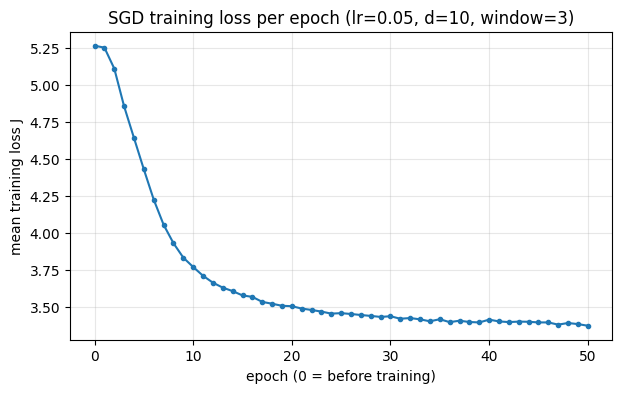

In [17]:
import matplotlib.pyplot as plt

epochs = range(len(history))                 # 0 = before training
plt.figure(figsize=(7, 4))
plt.plot(epochs, history, marker="o", markersize=3)
plt.xlabel("epoch (0 = before training)")
plt.ylabel("mean training loss J")
plt.title(f"SGD training loss per epoch (lr={LR}, d={DIM}, window={WINDOW})")
plt.grid(alpha=0.3)
plt.show()

In [18]:
import random

def numerical_check(model, i, t, eps=1e-5, n_u=30, seed=0):
    """Max |analytic - numeric| over all of E[i] and a random sample of U entries."""
    rnd = random.Random(seed)
    gU, gh, _ = model.gradients(i, t)

    def num(M, r, c):                                   # [L(x+eps) - L(x-eps)] / (2 eps)
        orig = M[r][c]
        M[r][c] = orig + eps; up = model.pair_loss(i, t)
        M[r][c] = orig - eps; down = model.pair_loss(i, t)
        M[r][c] = orig                                  # restore exactly
        return (up - down) / (2 * eps)

    errs = [abs(num(model.E, i, k) - gh[k]) for k in range(model.d)]
    for _ in range(n_u):
        k, j = rnd.randrange(model.d), rnd.randrange(model.V)
        errs.append(abs(num(model.U, k, j) - gU[k][j]))
    return max(errs)

for (i, t) in random.Random(1).sample(pairs, 3):
    err = numerical_check(model, i, t)
    print(pre.id2word[i], "->", pre.id2word[t], " max error =", f"{err:.2e}", " OK" if err < 1e-6 else " CHECK")

ነቲ -> ቦታ  max error = 6.53e-11  OK
እምበኣር -> ራእይ  max error = 8.65e-11  OK
ዝኾነ -> ክርስቶስ  max error = 5.11e-11  OK


## Query Learned Embeddings
### Query Nearest Neighbors

In [19]:
emb = Embeddings(model.E, pre.word2id, pre.id2word)
for w in ["ራእይ", "ምህራም", "ዋጋ", "ኢድ", "ማሽን", "ጨው", "ትማሊ", "ሰብ"]:
    res = emb.nearest(w, k=3)
    print(w, res if res else "not in vocabulary")       



ራእይ [('በዓል', 0.9457), ('ምርኣይ', 0.9228), ('ግና', 0.8599)]
ምህራም [('ንሱ', 0.8715), ('ኸኣ', 0.8582), ('ይጽግን', 0.8344)]
ዋጋ [('ኢና', 0.8222), ('ምህራም', 0.7791), ('ኸኣ', 0.7698)]
ኢድ [('ዘሎ', 0.9225), ('ዘይኮነስ', 0.8614), ('ምኽንያቱ', 0.8456)]
ማሽን [('ሓንሳብ', 0.7798), ('ናይቲ', 0.7704), ('ንሳቶም', 0.7436)]
ጨው [('መግቢ', 0.9415), ('ተወሳኺ', 0.8478), ('ጥቕሚ', 0.8404)]
ትማሊ [('ሎሚ', 0.9221), ('ስለዚ', 0.7825), ('ይኽእል', 0.7793)]
ሰብ [('ልቢ', 0.8359), ('ኢሉ', 0.7464), ('ያ', 0.7463)]


### Conclusion: essay experiment

Settings: seed 42, d = 10, window 3, learning rate 0.05, 50 epochs, min_count = 2.

Mean training loss fell from 5.26 (about ln V, a uniform guess) to 3.38 and flattened
after roughly epoch 40. The numerical gradient check on this model passed, with errors
around 1e-10.

Words that occur in many sentences got meaningful neighbors: ጨው (salt) → መግቢ (food), ጥቕሚ
(benefit); ትማሊ (yesterday) → ሎሚ (today); ራእይ (vision) → በዓል, ምርኣይ (seeing). Words with
loose contexts (ማሽን, ኢድ, ዋጋ) still got mostly function words, and the apostrophe-splitting
artifact `ያ` remained in the vocabulary. Setting min_count = 2 removed words seen once, which
eliminated the memorization-style neighbors with very high cosine scores (such as ታሪኽ and
ምስጢር in an earlier run), but it also removed some rare informative neighbors, such as
ብልሽቱ for ማሽን.

### Save and Reload Model

In [20]:
model.save("models/tigrinya_essay.json", pre.id2word,
           meta={"window": WINDOW, "lr": LR, "epochs": EPOCHS, "loss_history": history})

model2, vocab2 = SkipGram.load("models/tigrinya_essay.json")
print(model2.meta)

{'seed': 42, 'vocab_size': 193, 'dim': 10, 'window': 3, 'lr': 0.05, 'epochs': 50, 'loss_history': [5.262677978136013, 5.249819717571577, 5.108437760718851, 4.853254940547877, 4.64036255403842, 4.428827633617251, 4.225447928669823, 4.056475029532151, 3.9319445784604667, 3.834518609123009, 3.771639264080608, 3.7123637961271063, 3.6659381178762054, 3.632520026986385, 3.609183560749179, 3.5800866636016164, 3.5703312669653617, 3.5364767063890414, 3.5241728961140306, 3.5102737894703835, 3.507464410839317, 3.4916464039900674, 3.482060572963754, 3.4711785787684386, 3.4574840809708025, 3.4606485216741625, 3.4550226932967996, 3.448152006265161, 3.44209404095212, 3.435232709389675, 3.439831451384201, 3.4229899841852895, 3.42765107220562, 3.4189441074114977, 3.4057510560002426, 3.4196714946713573, 3.4000850657904254, 3.40970234151244, 3.4010086051230015, 3.3980416886156615, 3.4168778394631714, 3.404990909473016, 3.400438320289016, 3.4036270575719576, 3.4025564265840273, 3.3981559200935956, 3.39817